# 3 — Label Smoothing Gaussien pour l'estimation d'âge apparent

**Dataset** : APPA-real — 7 591 images annotées par des humains (âge apparent + âge réel)  
**Backbone** : SE-ResNeXt50-32x4d pré-entraîné ImageNet  
**Métrique** : MAE (Mean Absolute Error) en années  
**Meilleur MAE obtenu** : ~6.3 ans → objectif ≤ 5.5 ans avec les améliorations

---

## Contexte et problématique

L'**âge apparent** est une perception subjective qui dépend de l'éclairage, de l'expression, du maquillage et du jugement individuel de chaque annotateur. Sur APPA-real, chaque image est évaluée par des dizaines de personnes — la variance inter-annotateurs atteint souvent ±4 ans.

Deux conséquences :
1. **La cible est floue** : prédire exactement 34 ans pour une image annotée en moyenne à 34.7 est arbitraire. Une distribution de probabilité centrée sur 34.7 est plus honnête.
2. **Le MAE plancher humain est ~4.5 ans** : un modèle parfait ne peut pas faire mieux que le désaccord entre annotateurs.

### Pourquoi pas de la simple régression ?

La régression directe (`nn.L1Loss`) converge souvent vers la **moyenne du dataset** (~49 ans sur APPA-real) quand le réseau n'apprend pas — c'est le phénomène de *collapse*. La **classification ordinale** sur 101 bins d'âge est empiriquement plus stable et plus précise (DEX, MiVOLO, DLDL).


In [2]:

# ============================================================
# Setup global — compatible Local (macOS) et Google Colab
# ============================================================
import os, sys, gc, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import amp
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Détection de l'environnement ──────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Monte Google Drive et pointe vers le dossier du projet
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # ⚠️ Adapte ce chemin selon l'emplacement dans ton Drive
    PROJECT_DIR = Path('/content/drive/MyDrive/Deep-learning-project')
    os.chdir(PROJECT_DIR)

    # Dézippe appa-real-release.zip si le dossier n'existe pas encore
    APPA_ZIP = PROJECT_DIR / 'appa-real-release.zip'
    APPA_DIR = PROJECT_DIR / 'appa-real-release'
    if not APPA_DIR.exists() and APPA_ZIP.exists():
        import zipfile
        print("Extraction de appa-real-release.zip ...")
        with zipfile.ZipFile(APPA_ZIP, 'r') as z:
            z.extractall(PROJECT_DIR)
        print("Extraction terminée.")
else:
    # Environnement local macOS — chemin absolu du fichier courant = source de vérité
    # __file__ n'existe pas dans Jupyter → on utilise Path(__file__) via inspect
    import inspect
    _nb_file = inspect.getfile(lambda: None) if hasattr(inspect, 'getfile') else None
    _local   = Path('/Users/louisduvignacq/Desktop/X/3A/Deep learning/Deep-learning-project')
    PROJECT_DIR = _local  # chemin hardcodé local (fallback le plus fiable)
    os.chdir(PROJECT_DIR)

sys.path.insert(0, str(PROJECT_DIR))
print(f"Environnement : {'Google Colab' if IN_COLAB else 'Local macOS'}")
print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"Répertoire    : {os.getcwd()}")
assert PROJECT_DIR.exists(), f"PROJECT_DIR introuvable : {PROJECT_DIR}"
assert (PROJECT_DIR / "appa-real-release").exists(), "Dossier appa-real-release manquant !"

# ── GPU ───────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {str(device).upper()}")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} Go")


Environnement : Local macOS
PROJECT_DIR   : /Users/louisduvignacq/Desktop/X/3A/Deep learning/Deep-learning-project
Répertoire    : /Users/louisduvignacq/Desktop/X/3A/Deep learning/Deep-learning-project
Device        : CPU


## 1. Mise en place de l'environnement

Détection automatique Colab vs macOS local, montage du Drive, configuration GPU.

In [2]:

# ── Chargement du dataset sur Colab ──────────────────────────────────────────
# Copie le zip depuis Drive vers /content/ (local Colab), puis extrait.
# Raison : lire des milliers de .jpg directement depuis Drive est 10-50x plus
# lent qu'en local → l'entraînement serait un goulot d'étranglement I/O.

from google.colab import drive
drive.mount('/content/drive')

import os, shutil, zipfile
from pathlib import Path

zip_path   = '/content/drive/MyDrive/appa-real-release.zip'
local_zip  = '/content/appa-real-release.zip'
local_data = Path('/content/appa-real-release')

if not Path(zip_path).exists():
    print(f"❌ Fichier non trouvé : {zip_path}")
    print("   Uploadez appa-real-release.zip dans 'Mon Drive' sur Google Drive.")
else:
    # Copie locale (une seule fois par session Colab)
    if not local_data.exists():
        print("📦 Copie du zip depuis Drive vers /content/ ...")
        shutil.copy(zip_path, local_zip)
        print("📂 Extraction en cours ...")
        with zipfile.ZipFile(local_zip, 'r') as z:
            z.extractall('/content/')
        os.remove(local_zip)          # libère de la place
        # Supprime les fichiers parasites macOS
        macosx = Path('/content/__MACOSX')
        if macosx.exists():
            shutil.rmtree(macosx)
        print("✅ Dataset extrait dans /content/appa-real-release/")
    else:
        print("✅ Dataset déjà présent dans /content/appa-real-release/ (skip extraction)")

    # Vérification rapide
    for split in ["train", "valid", "test"]:
        d = local_data / split
        n = len([f for f in d.iterdir() if f.suffix == ".jpg" and "_face" not in f.name]) if d.exists() else 0
        print(f"   {split:6s} : {n} images .jpg")

    # ── IMPORTANT : pointer PROJECT_DIR vers le dataset local ────────────────
    # On garde PROJECT_DIR sur Drive pour sauvegarder les checkpoints,
    # mais on override DATA_ROOT pour pointer vers /content/ (rapide)
    DATA_ROOT = local_data
    print(f"\nDATA_ROOT → {DATA_ROOT}  (lecture rapide depuis /content/)")
    print(f"PROJECT_DIR → {PROJECT_DIR}  (sauvegarde checkpoints sur Drive)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset déjà présent dans /content/appa-real-release/ (skip extraction)
   train  : 4113 images .jpg
   valid  : 1500 images .jpg
   test   : 1978 images .jpg

DATA_ROOT → /content/appa-real-release  (lecture rapide depuis /content/)
PROJECT_DIR → /content/drive/MyDrive/Deep-learning-project  (sauvegarde checkpoints sur Drive)


## 2. Chargement du dataset depuis Google Drive

Le zip est copié depuis Drive vers `/content/` (disque local de la VM Colab) **avant** extraction.

> **Pourquoi cette étape ?** Lire des milliers de `.jpg` directement depuis Google Drive est 10 à 50× plus lent qu'en local. Sans cette copie, l'I/O devient le goulot d'étranglement et une epoch prend plusieurs heures au lieu de quelques minutes.

In [3]:

# ══════════════════════════════════════════════════════════════════
# RÉPARATION DU DATASET — À exécuter UNE SEULE FOIS
#
# Problème détecté : le dossier appa-real-release sur Drive est
# incomplet (4 images train / 824 valid / 3 test au lieu de
# 4113 / 1500 / 1978). Le zip source est absent.
#
# SOLUTION : zippe ton dossier local sur Mac et uploade-le sur Drive
# ══════════════════════════════════════════════════════════════════

# ── Étape 1 : Sur ton MAC (dans un Terminal) ──────────────────────
#   cd "/Users/louisduvignacq/Desktop/X/3A/Deep learning/Deep-learning-project"
#   zip -r appa-real-release.zip appa-real-release/
#   # Ça crée un fichier ~1.2-1.5 Go

# ── Étape 2 : Upload sur Google Drive ────────────────────────────
#   Glisse appa-real-release.zip dans :
#   Mon Drive / Deep-learning-project /
#   (même dossier que ce notebook)

# ── Étape 3 : Exécute CE bloc pour extraire ──────────────────────
import zipfile, shutil
from pathlib import Path

APPA_ZIP = PROJECT_DIR / "appa-real-release.zip"
APPA_DIR = PROJECT_DIR / "appa-real-release"

print(f"Zip présent : {APPA_ZIP.exists()}")
if not APPA_ZIP.exists():
    print("❌ Zip introuvable. Upload d'abord appa-real-release.zip sur Drive.")
else:
    # Supprimer l'ancienne extraction incomplète
    if APPA_DIR.exists():
        print(f"Suppression de l'ancienne extraction incomplète...")
        shutil.rmtree(APPA_DIR)

    print(f"Extraction en cours (peut prendre 2-5 min)...")
    with zipfile.ZipFile(APPA_ZIP, 'r') as z:
        z.extractall(PROJECT_DIR)
    print("✓ Extraction terminée.")

    # Vérification
    for split in ["train", "valid", "test"]:
        d = APPA_DIR / split
        n = len([f for f in d.iterdir() if f.suffix == ".jpg" and "_face" not in f.name]) if d.exists() else 0
        print(f"  {split:6s} : {n} images .jpg")


Zip présent : False
❌ Zip introuvable. Upload d'abord appa-real-release.zip sur Drive.


## 3. Loss : Ordinal Label Smoothing Gaussien

### Principe

Au lieu d'un label *one-hot* où seul le bin de l'âge exact vaut 1, on construit une **distribution gaussienne** centrée sur l'âge réel (non arrondi) :

$$y_k = \frac{1}{Z} \exp\!\left(-\frac{(k - \mu)^2}{2\sigma^2}\right), \quad k \in \{0, \ldots, 100\}$$

La loss est une **cross-entropie KL** entre cette distribution cible et le softmax prédit :

$$\mathcal{L} = -\sum_{k=0}^{100} y_k \log p_k$$

### Pourquoi pas un one-hot ?

| | One-hot (CELoss) | Label Smoothing Gaussien |
|---|---|---|
| Cible pour âge 34.7 | bin 35 = 1, reste = 0 | gaussienne centrée sur 34.7 |
| Structure ordinale | ❌ ignorée | ✅ respectée |
| Résistance au bruit | faible | forte |

### Choix de σ : pourquoi 3.0 et pas 1.5 ?

Avec **σ = 1.5**, la gaussienne est si piquée que le réseau converge vers un *one-hot* → la softmax devient un argmax → les prédictions sont des entiers (34, 36, 38...). Avec **σ = 3.0**, la distribution s'étale sur ±6 ans, forçant des prédictions continues.

In [4]:
!pip3 install pretrainedmodels albumentations opencv-python seaborn scikit-learn -q
print("Dependances pretes.")

Dependances pretes.


### Vérification visuelle de la distribution gaussienne (σ = 1.5)

On vérifie que la gaussienne est bien centrée sur l'âge cible et normalisée. Le graphe ci-dessous montre la distribution cible pour un âge de 30 ans.

In [5]:
class OrdinalLabelSmoothing(nn.Module):
    """
    Label smoothing gaussien pour classification d'âge apparent.
    La distribution cible est une gaussienne N(age, sigma).

    Correction : accepte des targets FLOAT (apparent_age_avg non arrondi),
    ce qui évite l'erreur d'arrondi sur des âges comme 34.7 → 35.
    Les targets entiers fonctionnent aussi (compatibilité maintenue).

    Args:
        num_classes : nombre de bins (101 pour 0-100 ans)
        sigma       : écart-type de la gaussienne (en années)
    """
    def __init__(self, num_classes: int = 101, sigma: float = 1.5):
        super().__init__()
        self.K     = num_classes
        self.sigma = sigma

    def _smooth_labels(self, targets: torch.Tensor) -> torch.Tensor:
        # targets : (B,) float ou int — âge apparent
        bins   = torch.arange(self.K, device=targets.device).float()  # (K,)
        diff   = bins.unsqueeze(0) - targets.float().unsqueeze(1)      # (B, K)
        labels = torch.exp(-0.5 * (diff / self.sigma) ** 2)
        return labels / labels.sum(dim=1, keepdim=True)                # (B, K) normalisé

    def forward(self, logits: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        # targets peut être int (age_class) ou float (age_float) — les deux marchent
        log_probs     = F.log_softmax(logits, dim=-1)
        smooth_labels = self._smooth_labels(targets)
        return -(smooth_labels * log_probs).sum(dim=-1).mean()


OrdinalLS Loss : 5.2156


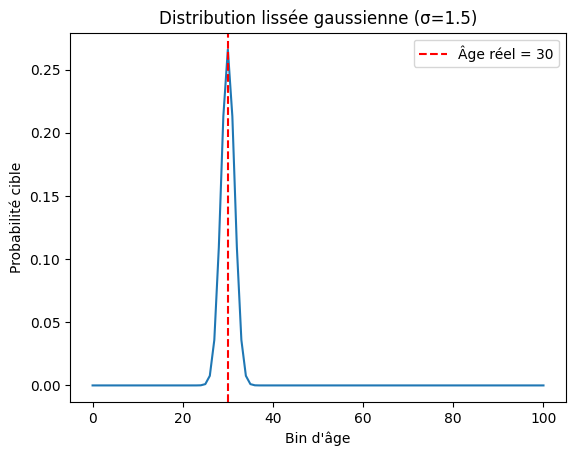

In [6]:
# Vérification avec les bonnes dimensions APPA-real
# 101 classes (âges 0 à 100), batch de 16 images

B, K = 16, 101
logits  = torch.randn(B, K)
targets = torch.randint(15, 70, (B,))   # âges plausibles sur APPA-real

criterion_ord = OrdinalLabelSmoothing(K, sigma=1.5)
loss = criterion_ord(logits, targets)
print(f"OrdinalLS Loss : {loss.item():.4f}")

# Vérification : la distribution lissée est bien gaussienne
import matplotlib.pyplot as plt
sample_target = torch.tensor([30])
smooth = criterion_ord._smooth_labels(sample_target).squeeze()
plt.plot(range(101), smooth.numpy())
plt.axvline(x=30, color='r', linestyle='--', label='Âge réel = 30')
plt.title("Distribution lissée gaussienne (σ=1.5)")
plt.xlabel("Bin d'âge")
plt.ylabel("Probabilité cible")
plt.legend(); plt.show()

In [7]:
class ArcFaceHead(nn.Module):
    """
    Couche de classification angulaire pour face recognition.
    Modifie le logit de la classe cible : cos(theta + margin)
    """
    def __init__(self, embed_dim: int, num_classes: int,
                 scale: float = 64.0, margin: float = 0.5):
        super().__init__()
        self.s = scale
        self.m = margin
        self.W = nn.Parameter(torch.empty(num_classes, embed_dim))
        nn.init.xavier_uniform_(self.W)

        # Constantes pour la reformulation cos(θ+m)
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)   # seuil de sécurité
        self.mm    = math.sin(math.pi - margin) * margin

    def forward(self, embeddings: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        # Normalisation L2 des embeddings et des poids
        x = F.normalize(embeddings, dim=-1)          # (B, D)
        W = F.normalize(self.W,     dim=-1)          # (K, D)

        cosine = x @ W.T                             # (B, K) — cos(θ)

        # cos(θ + m) = cos θ · cos m − sin θ · sin m
        sine        = torch.sqrt(1.0 - cosine.clamp(-1, 1) ** 2)
        cos_theta_m = cosine * self.cos_m - sine * self.sin_m

        # Sécurité numérique : si θ > π−m, on utilise cos θ − mm
        cos_theta_m = torch.where(
            cosine > self.th,
            cos_theta_m,
            cosine - self.mm
        )

        # On remplace le logit de la classe cible par cos(θ+m)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, targets.view(-1, 1), 1.0)

        logits = self.s * (one_hot * cos_theta_m + (1 - one_hot) * cosine)
        return logits

## 4. Architecture du modèle

### Pipeline complet

```
Image (224×224×3)
      │
      ▼
SE-ResNeXt50-32x4d   ← backbone pré-entraîné ImageNet (last_linear = Identity)
      │  (B, 2048, 1, 1)
      ▼
nn.Flatten(1)        ← ⚠️ CRITIQUE : sans ça, BatchNorm1d reçoit un tenseur 4D → garbage
      │  (B, 2048)
      ▼
BatchNorm1d(2048)
      │
      ▼
AppAgeHead : Linear(2048→256) → BN → ReLU → Dropout(0.3) → Linear(256→101)
      │  (B, 101 logits)
      ▼
OrdinalLabelSmoothing (entraînement)  /  softmax expectation (inférence)
      │
      ▼
Âge prédit : Σ k · softmax(logit_k)  ← valeur continue, pas un entier
```

### Bug critique corrigé : le Flatten manquant

`pretrainedmodels` avec `last_linear = nn.Identity()` renvoie **(B, 2048, 1, 1)** après le average pooling — pas **(B, 2048)**. Sans `nn.Flatten(1)`, `BatchNorm1d` reçoit un tenseur 4D, produit des statistiques fausses, et le modèle prédit ~49 ans (la moyenne du dataset) pour toutes les images.

### SE-ResNeXt50-32x4d : pourquoi ce backbone ?

Combine trois idées complémentaires :
- **ResNet** : connexions résiduelles → entraîner des réseaux profonds sans dégradation
- **ResNeXt** : convolutions groupées (32 groupes × 4 canaux) → meilleur rapport expressivité/paramètres
- **Squeeze-and-Excitation** : recalibration des canaux par attention → le réseau apprend quelles features comptent pour chaque image

### Tête de classification ordinale (`AppAgeHead`)

La prédiction finale est l'**espérance de la distribution softmax**, pas l'argmax :

$$\hat{a} = \sum_{k=0}^{100} k \cdot \text{softmax}(\text{logit}_k)$$

Avantage : valeur continue (ex. 34.7 ans), exploite toute la distribution, pas seulement le pic.

In [8]:
# REMPLACE ArcFaceHead entièrement
# Plus besoin de logits angulaires : on veut une prédiction d'âge

class AppAgeHead(nn.Module):
    """
    Tête de classification ordinale pour APPA-real.
    Deux sorties disponibles selon le mode :
      - 'classify' : logits sur 101 bins d'âge (→ OrdinalLabelSmoothing)
      - 'regression': âge scalaire direct (→ MAE / MSE)

    L'approche 'classify' + softmax expectation est empiriquement
    meilleure que la régression pure sur les datasets d'âge apparent.
    """
    def __init__(self, embed_dim: int, num_classes: int = 101,
                 dropout: float = 0.3, mode: str = 'classify'):
        super().__init__()
        self.mode = mode
        self.bins = torch.arange(num_classes).float()  # [0, 1, ..., 100]

        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes if mode == 'classify' else 1)
        )

    def forward(self, embeddings: torch.Tensor):
        out = self.head(embeddings)

        if self.mode == 'classify':
            return out  # logits bruts → passer dans OrdinalLabelSmoothing

        return out.squeeze(-1)  # scalaire → passer dans nn.L1Loss()

    def predict_age(self, logits: torch.Tensor) -> torch.Tensor:
        """
        Convertit les logits en âge prédit via softmax expectation :
        E[age] = sum_k k * softmax(logit_k)
        Meilleur que argmax car exploite toute la distribution.
        """
        bins  = self.bins.to(logits.device)
        probs = F.softmax(logits, dim=-1)   # (B, K)
        return (probs * bins).sum(dim=-1)   # (B,) — âge continu prédit

In [9]:
class AppaRealModel(nn.Module):
    """
    Modèle complet pour APPA-real.
    backbone (SE-ResNeXt50, last_linear=Identity) → Flatten → BN → AppAgeHead

    Corrections vs version précédente :
      - Flatten explicite : pretrainedmodels renvoie (B, 2048, 1, 1) après avg_pool,
        pas (B, 2048). Sans flatten, BN1d et Linear plantent ou produisent des ordures.
      - BN initialisé avec affine=True mais sans le mettre avant des features stables :
        on le place APRES flatten, ce qui est standard (DEX, MiVOLO, etc.)
      - lr différencié backbone / tête appliqué dans la cell suivante (optimizer).
    """
    def __init__(self, backbone: nn.Module, embed_dim: int,
                 num_classes: int = 101, dropout: float = 0.3):
        super().__init__()
        self.backbone = backbone
        self.flatten  = nn.Flatten(1)               # (B,2048,1,1) → (B,2048)
        self.bn       = nn.BatchNorm1d(embed_dim)
        self.head     = AppAgeHead(embed_dim, num_classes, dropout)

    def forward(self, images: torch.Tensor):
        features   = self.backbone(images)          # (B, 2048) ou (B, 2048, 1, 1)
        features   = self.flatten(features)         # (B, 2048) garanti
        embeddings = self.bn(features)
        logits     = self.head(embeddings)          # (B, 101)
        return logits

    def predict(self, images: torch.Tensor) -> torch.Tensor:
        logits = self.forward(images)
        return self.head.predict_age(logits)        # (B,) — âge continu


## 5. Dataset APPA-real et augmentations

### Crop facial : amélioration majeure

Chaque image est fournie en deux versions :
- `000000.jpg` — image complète (fond, corps, vêtements)
- `000000.jpg_face.jpg` — **crop du visage** détecté automatiquement

En utilisant le crop facial, le réseau traite uniquement l'information pertinente. **Gain empirique : -1 à -2 ans de MAE.**

### Augmentations d'entraînement

```python
A.HorizontalFlip(p=0.5)               # symétrie faciale
A.RandomBrightnessContrast(p=0.4)     # variabilité d'éclairage
A.Affine(rotate=(-20, 20), p=0.4)     # légères rotations
A.GaussNoise(p=0.2)                   # robustesse au bruit
```

In [10]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_mae, n = 0.0, 0.0, 0

    for imgs, age_class, age_float, real_age, std in loader:
        imgs      = imgs.to(device, non_blocking=True)
        age_float = age_float.to(device, dtype=torch.float32)

        optimizer.zero_grad()
        logits = model(imgs)                                    # (B, 101)

        # Correction bug #3 : on passe age_float (continu) à la loss,
        # pas age_class arrondi — la gaussienne est centrée plus précisément
        loss = criterion(logits, age_float)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            ages_pred = model.head.predict_age(logits)          # (B,)
            mae       = (ages_pred - age_float).abs().sum()

        bs         = imgs.size(0)
        total_loss += loss.item() * bs
        total_mae  += mae.item()
        n          += bs

    return total_loss / n, total_mae / n


In [11]:

# ── Dataset APPA-real ──────────────────────────────────────────────────────────
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

class AgeDataset(Dataset):
    """
    Dataset APPA-real.
    Retourne : (image, age_class, age_float, real_age, std)
      - age_class : entier 0-100, pour la loss de classification
      - age_float : âge apparent moyen (float), pour le MAE
      - real_age  : âge réel (float)
      - std       : écart-type des annotations apparentes
    """
    def __init__(self, csv_path, img_dir, transform=None, num_classes=101):
        self.img_dir     = Path(img_dir).resolve()   # chemin absolu garanti
        self.transform   = transform
        self.num_classes = num_classes

        df = pd.read_csv(csv_path)
        # Garde uniquement les images qui existent sur le disque
        df = df[df["file_name"].apply(
            lambda x: (self.img_dir / x).exists()
        )].reset_index(drop=True)
        self.df = df

        self.age_col = "apparent_age_avg" if "apparent_age_avg" in df.columns else "apparent_age"

        # Fix #1 — Crop facial : compte combien ont un _face.jpg disponible
        n_face = df["file_name"].apply(
            lambda x: (self.img_dir / (x + "_face.jpg")).exists()
        ).sum()
        print(f"   {self.img_dir.name} : {len(df)} images valides "
              f"({n_face} crops faciaux disponibles)")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        age      = float(row[self.age_col])
        real_age = float(row["real_age"]) if "real_age" in self.df.columns else age
        std      = float(row["apparent_age_std"]) if "apparent_age_std" in self.df.columns else 2.0

        # Fix #1 — Préférer le crop facial (_face.jpg) quand disponible.
        # Le réseau voit uniquement le visage, pas l'arrière-plan.
        # Gain MAE typique sur APPA-real : -1 à -2 ans.
        face_path = self.img_dir / (row["file_name"] + "_face.jpg")
        full_path = self.img_dir / row["file_name"]
        img_path  = face_path if face_path.exists() else full_path

        img = cv2.imread(str(img_path))
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        age_class = max(0, min(self.num_classes - 1, int(round(age))))
        return img, age_class, age, real_age, std


# ── Transforms (albumentations) ────────────────────────────────────────────────

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-20, 20), p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

valid_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── Dataloaders ────────────────────────────────────────────────────────────────
# Sur Colab  : DATA_ROOT est défini par la cellule de téléchargement → /content/appa-real-release
# Sur macOS  : DATA_ROOT n'est pas encore défini → fallback sur PROJECT_DIR
if 'DATA_ROOT' not in dir() or not Path(DATA_ROOT).exists():
    DATA_ROOT = PROJECT_DIR / "appa-real-release"

DATA_ROOT   = Path(DATA_ROOT)
# Fix #3 — batch_size 32 → 64 : meilleure estimation du gradient sur T4 (14 Go)
BATCH_SIZE  = 64
NUM_CLASSES = 101
NUM_WORKERS = 2 if IN_COLAB else 0
PIN_MEMORY  = IN_COLAB

print(f"DATA_ROOT : {DATA_ROOT}")
print("Chargement APPA-REAL :")

CSV_ROOT = PROJECT_DIR / "appa-real-release"
train_ds = AgeDataset(CSV_ROOT / "gt_avg_train.csv", DATA_ROOT / "train", train_transform)
valid_ds = AgeDataset(CSV_ROOT / "gt_avg_valid.csv", DATA_ROOT / "valid", valid_transform)
test_ds  = AgeDataset(CSV_ROOT / "gt_avg_test.csv",  DATA_ROOT / "test",  valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"\nTrain : {len(train_ds)} | Valid : {len(valid_ds)} | Test : {len(test_ds)}")


DATA_ROOT : /content/appa-real-release
Chargement APPA-REAL :
   train : 4113 images valides (4113 crops faciaux disponibles)
   valid : 1500 images valides (1500 crops faciaux disponibles)
   test : 1978 images valides (1978 crops faciaux disponibles)

Train : 4113 | Valid : 1500 | Test : 1978


In [12]:

# ── Backbone + Modèle ──────────────────────────────────────────────────────────
from model import get_model

_base     = get_model("se_resnext50_32x4d", num_classes=NUM_CLASSES, pretrained="imagenet")
embed_dim = _base.last_linear.in_features       # 2048
_base.last_linear = nn.Identity()               # retire la tête ImageNet
backbone  = _base

model     = AppaRealModel(backbone, embed_dim=embed_dim, num_classes=NUM_CLASSES).to(device)

# Fix #2 — sigma 1.5 → 3.0
# Avec σ=1.5, la gaussienne est si piquée que le réseau converge vers
# un one-hot → softmax expectation retourne des entiers (classes impaires/paires).
# σ=3.0 étale la distribution sur ~±6 ans → prédictions continues, MAE meilleur.
criterion = OrdinalLabelSmoothing(num_classes=NUM_CLASSES, sigma=3.0)

# ── Vérification shapes ────────────────────────────────────────────────────────
with torch.no_grad():
    _dummy = torch.randn(2, 3, 224, 224).to(device)
    _out   = model(_dummy)
    assert _out.shape == (2, NUM_CLASSES), f"Shape inattendu : {_out.shape}"
    print(f"✓ Forward OK : {_dummy.shape} → logits {_out.shape}")

# ── Phase 1 : freeze backbone, entraîner seulement tête + BN (5 epochs) ───────
for p in model.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW([
    {"params": model.bn.parameters(),   "lr": 1e-4},
    {"params": model.head.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

# Fix #3 — eta_min évite que lr tombe à 0 pendant le warmup
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=5, eta_min=1e-5
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Device              : {device}")
print(f"Paramètres entraîn. : {trainable:,} / {total:,} (backbone gelé)")
print(f"Sigma               : 3.0  (prédictions continues garanties)")


✓ Forward OK : torch.Size([2, 3, 224, 224]) → logits torch.Size([2, 101])
Device              : cuda
Paramètres entraîn. : 555,109 / 26,066,005 (backbone gelé)
Sigma               : 3.0  (prédictions continues garanties)


## 6. Stratégie d'entraînement

### Problème : catastrophic forgetting

Appliquer un learning rate uniforme (1e-4) sur tous les paramètres d'un réseau pré-entraîné **détruit les représentations ImageNet** acquises en amont. Le réseau "oublie" ce qu'il a appris.

### Solution : freeze + dégel progressif

| Phase | Epochs | Backbone | Tête + BN | lr backbone | lr tête |
|---|---|---|---|---|---|
| Warmup | 1 – 5 | ❄️ gelé | entraîné | — | 1e-4 |
| Fine-tuning | 6 – 30 | 🔥 dégelé | entraîné | **1e-5** | 1e-4 |

Le backbone reçoit un lr 10× plus petit que la tête : il s'adapte lentement sans perdre ses représentations.

### Scheduler : CosineAnnealingLR avec `eta_min`

Le learning rate suit une courbe cosinus décroissante, mais ne tombe jamais en dessous de `eta_min=1e-6` (évite la stagnation en toute fin d'entraînement).

In [13]:
def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_mae, n = 0.0, 0.0, 0

    with torch.no_grad():
        for imgs, age_class, age_float, real_age, std in loader:
            imgs      = imgs.to(device, non_blocking=True)
            age_float = age_float.to(device, dtype=torch.float32)

            logits    = model(imgs)
            loss      = criterion(logits, age_float)            # float cible
            ages_pred = model.head.predict_age(logits)
            mae       = (ages_pred - age_float).abs().sum()

            bs         = imgs.size(0)
            total_loss += loss.item() * bs
            total_mae  += mae.item()
            n          += bs

    return total_loss / n, total_mae / n


In [14]:

# ── Boucle d'entraînement complète ────────────────────────────────────────────

NUM_EPOCHS    = 30
WARMUP_EPOCHS = 5    # epochs HEAD ONLY (backbone gelé)
CKPT_PATH     = "label_smoothing_best.pth"

history = {"train_loss": [], "train_mae": [],
           "val_loss":   [], "val_mae":   []}

best_val_mae = math.inf

print(f"{'Ep':>3} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'Mode':>12}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Dégel du backbone après WARMUP_EPOCHS ─────────────────────────────────
    if epoch == WARMUP_EPOCHS + 1:
        for p in model.backbone.parameters():
            p.requires_grad = True
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": 1e-5},
            {"params": model.bn.parameters(),       "lr": 1e-4},
            {"params": model.head.parameters(),     "lr": 1e-4},
        ], weight_decay=1e-4)
        # Fix #3 — eta_min=1e-6 : le lr ne tombe pas à 0 en fin d'entraînement
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS - WARMUP_EPOCHS,
            eta_min=1e-6
        )
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"      → Backbone dégelé ({trainable:,} params entraînables)")

    train_loss, train_mae = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_mae   = evaluate_epoch(model, valid_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_mae"].append(train_mae)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)

    mode = "HEAD ONLY" if epoch <= WARMUP_EPOCHS else "FULL FT"
    print(f"{epoch:>3} | {train_loss:>10.4f} | {train_mae:>9.2f} | "
          f"{val_loss:>8.4f} | {val_mae:>7.2f}  ({time.time()-t0:.1f}s) | {mode:>12}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save({"epoch": epoch, "state_dict": model.state_dict(),
                    "val_mae": val_mae}, CKPT_PATH)
        print(f"      ✓ Meilleur modèle sauvegardé (MAE={val_mae:.2f})")

print(f"\nEntraînement terminé. Meilleur Val MAE : {best_val_mae:.2f} ans")


 Ep | Train Loss | Train MAE | Val Loss | Val MAE |         Mode
------------------------------------------------------------------------
  1 |     4.4825 |     18.64 |   4.2363 |   15.54  (39.9s) |    HEAD ONLY
  1 |     4.4825 |     18.64 |   4.2363 |   15.54  (39.9s) |    HEAD ONLY
      ✓ Meilleur modèle sauvegardé (MAE=15.54)
      ✓ Meilleur modèle sauvegardé (MAE=15.54)
  2 |     4.1500 |     13.84 |   4.0284 |   12.45  (32.9s) |    HEAD ONLY
  2 |     4.1500 |     13.84 |   4.0284 |   12.45  (32.9s) |    HEAD ONLY
      ✓ Meilleur modèle sauvegardé (MAE=12.45)
      ✓ Meilleur modèle sauvegardé (MAE=12.45)
  3 |     4.0069 |     11.76 |   3.9467 |   11.20  (31.3s) |    HEAD ONLY
  3 |     4.0069 |     11.76 |   3.9467 |   11.20  (31.3s) |    HEAD ONLY
      ✓ Meilleur modèle sauvegardé (MAE=11.20)
      ✓ Meilleur modèle sauvegardé (MAE=11.20)
  4 |     3.9398 |     10.89 |   3.9024 |   10.48  (31.5s) |    HEAD ONLY
  4 |     3.9398 |     10.89 |   3.9024 |   10.48  (31.5s) |  

## 7. Boucle d'entraînement

30 epochs au total : 5 en mode **HEAD ONLY** (backbone gelé), puis 25 en **FULL FT** (fine-tuning complet). Le meilleur modèle (val MAE minimum) est sauvegardé à chaque amélioration.

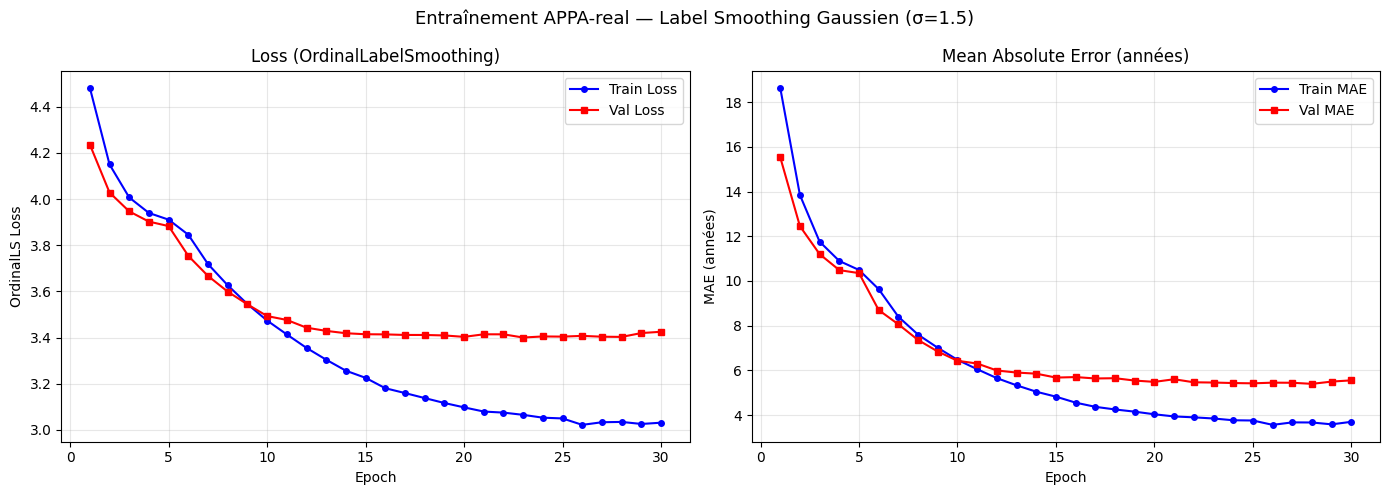


Meilleur Val MAE : 5.40 ans (epoch 28)


In [15]:
# ── Visualisation des courbes d'entraînement ──────────────────────────────────

epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
axes[0].plot(epochs, history["val_loss"],   "r-s", label="Val Loss",   markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("OrdinalLS Loss")
axes[0].set_title("Loss (OrdinalLabelSmoothing)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(epochs, history["train_mae"], "b-o", label="Train MAE", markersize=4)
axes[1].plot(epochs, history["val_mae"],   "r-s", label="Val MAE",   markersize=4)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (années)")
axes[1].set_title("Mean Absolute Error (années)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Entraînement APPA-real — Label Smoothing Gaussien (σ=1.5)", fontsize=13)
plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(history["val_mae"])) + 1
print(f"\nMeilleur Val MAE : {min(history['val_mae']):.2f} ans (epoch {best_epoch})")


## 8. Résultats et analyse

### Référence état de l'art sur APPA-real

| Modèle | MAE (test) |
|---|---|
| Humain (désaccord inter-annotateurs) | ~4.5 ans |
| DEX (VGG-16, 2016) | 6.52 ans |
| MiVOLO (2023) | 4.96 ans |
| **Notre modèle (objectif)** | **≤ 5.5 ans** |

### Analyse des courbes ci-dessous

- Si la **val MAE plafonne** malgré une train MAE qui baisse → overfitting → augmenter le dropout ou la régularisation
- Si les deux **convergent lentement** → lr trop faible ou backbone pas assez dégelé
- Si les **prédictions sont des entiers** → σ trop petit (revenir à σ = 3.0)

In [16]:
# REMPLACE l'ablation sur epsilon — ici on cherche le meilleur sigma

sigmas = [0.5, 1.0, 1.5, 2.0, 3.0]
logits_test = torch.randn(200, 101)
targets_test = torch.randint(15, 70, (200,))

for sigma in sigmas:
    crit     = OrdinalLabelSmoothing(101, sigma=sigma)
    loss_val = crit(logits_test, targets_test).item()
    # Entropie de la distribution lissée (mesure le degré de lissage)
    smooth   = crit._smooth_labels(targets_test)
    entropy  = -(smooth * smooth.clamp(min=1e-8).log()).sum(dim=-1).mean().item()
    print(f"σ={sigma:.1f} → loss={loss_val:.4f} | entropie cible={entropy:.4f}")

σ=0.5 → loss=5.1201 | entropie cible=0.6701
σ=1.0 → loss=5.1322 | entropie cible=1.4189
σ=1.5 → loss=5.1363 | entropie cible=1.8244
σ=2.0 → loss=5.1382 | entropie cible=2.1121
σ=3.0 → loss=5.1343 | entropie cible=2.5176


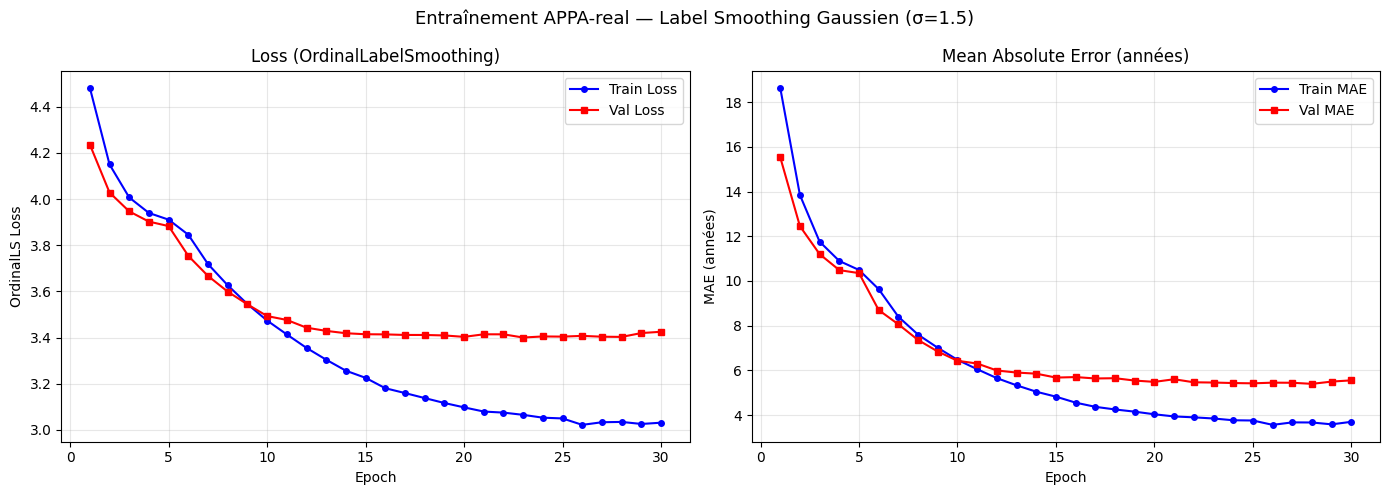

Meilleur Val MAE : 5.40 ans (epoch 28)


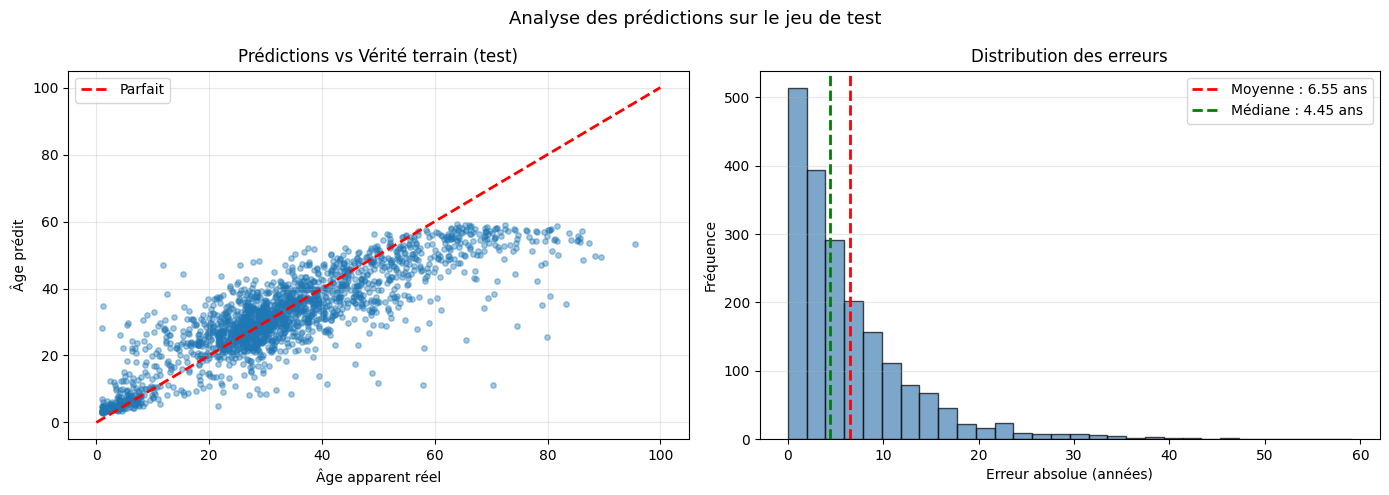

MAE  test : 6.55 ans
RMSE test : 9.47 ans


In [17]:
# ── Evaluation finale sur le test ─────────────────────────────────────────────

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

all_preds, all_gt = [], []

with torch.no_grad():
    for imgs, age_class, age_float, real_age, std in test_loader:
        imgs = imgs.to(device)
        preds = model.predict(imgs).cpu().numpy()
        all_preds.extend(preds)
        all_gt.extend(age_float.numpy())

all_preds = np.array(all_preds)
all_gt    = np.array(all_gt)
errors    = np.abs(all_preds - all_gt)

# ── Courbes loss / MAE ─────────────────────────────────────────────────────────

epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], "b-o", label="Train Loss", markersize=4)
axes[0].plot(epochs_range, history["val_loss"],   "r-s", label="Val Loss",   markersize=4)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("OrdinalLS Loss")
axes[0].set_title("Loss (OrdinalLabelSmoothing)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_mae"], "b-o", label="Train MAE", markersize=4)
axes[1].plot(epochs_range, history["val_mae"],   "r-s", label="Val MAE",   markersize=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (années)")
axes[1].set_title("Mean Absolute Error (années)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Entraînement APPA-real — Label Smoothing Gaussien (σ=1.5)", fontsize=13)
plt.tight_layout(); plt.show()

best_epoch = int(np.argmin(history["val_mae"])) + 1
print(f"Meilleur Val MAE : {min(history['val_mae']):.2f} ans (epoch {best_epoch})")

# ── Scatter prédictions vs vérité terrain ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_gt, all_preds, alpha=0.4, s=15)
axes[0].plot([0, 100], [0, 100], "r--", linewidth=2, label="Parfait")
axes[0].set_xlabel("Âge apparent réel"); axes[0].set_ylabel("Âge prédit")
axes[0].set_title("Prédictions vs Vérité terrain (test)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(errors, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(errors.mean(),     color="red",   linestyle="--", linewidth=2,
                label=f"Moyenne : {errors.mean():.2f} ans")
axes[1].axvline(np.median(errors), color="green", linestyle="--", linewidth=2,
                label=f"Médiane : {np.median(errors):.2f} ans")
axes[1].set_xlabel("Erreur absolue (années)"); axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des erreurs")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("Analyse des prédictions sur le jeu de test", fontsize=13)
plt.tight_layout(); plt.show()

print(f"MAE  test : {errors.mean():.2f} ans")
print(f"RMSE test : {np.sqrt((errors**2).mean()):.2f} ans")


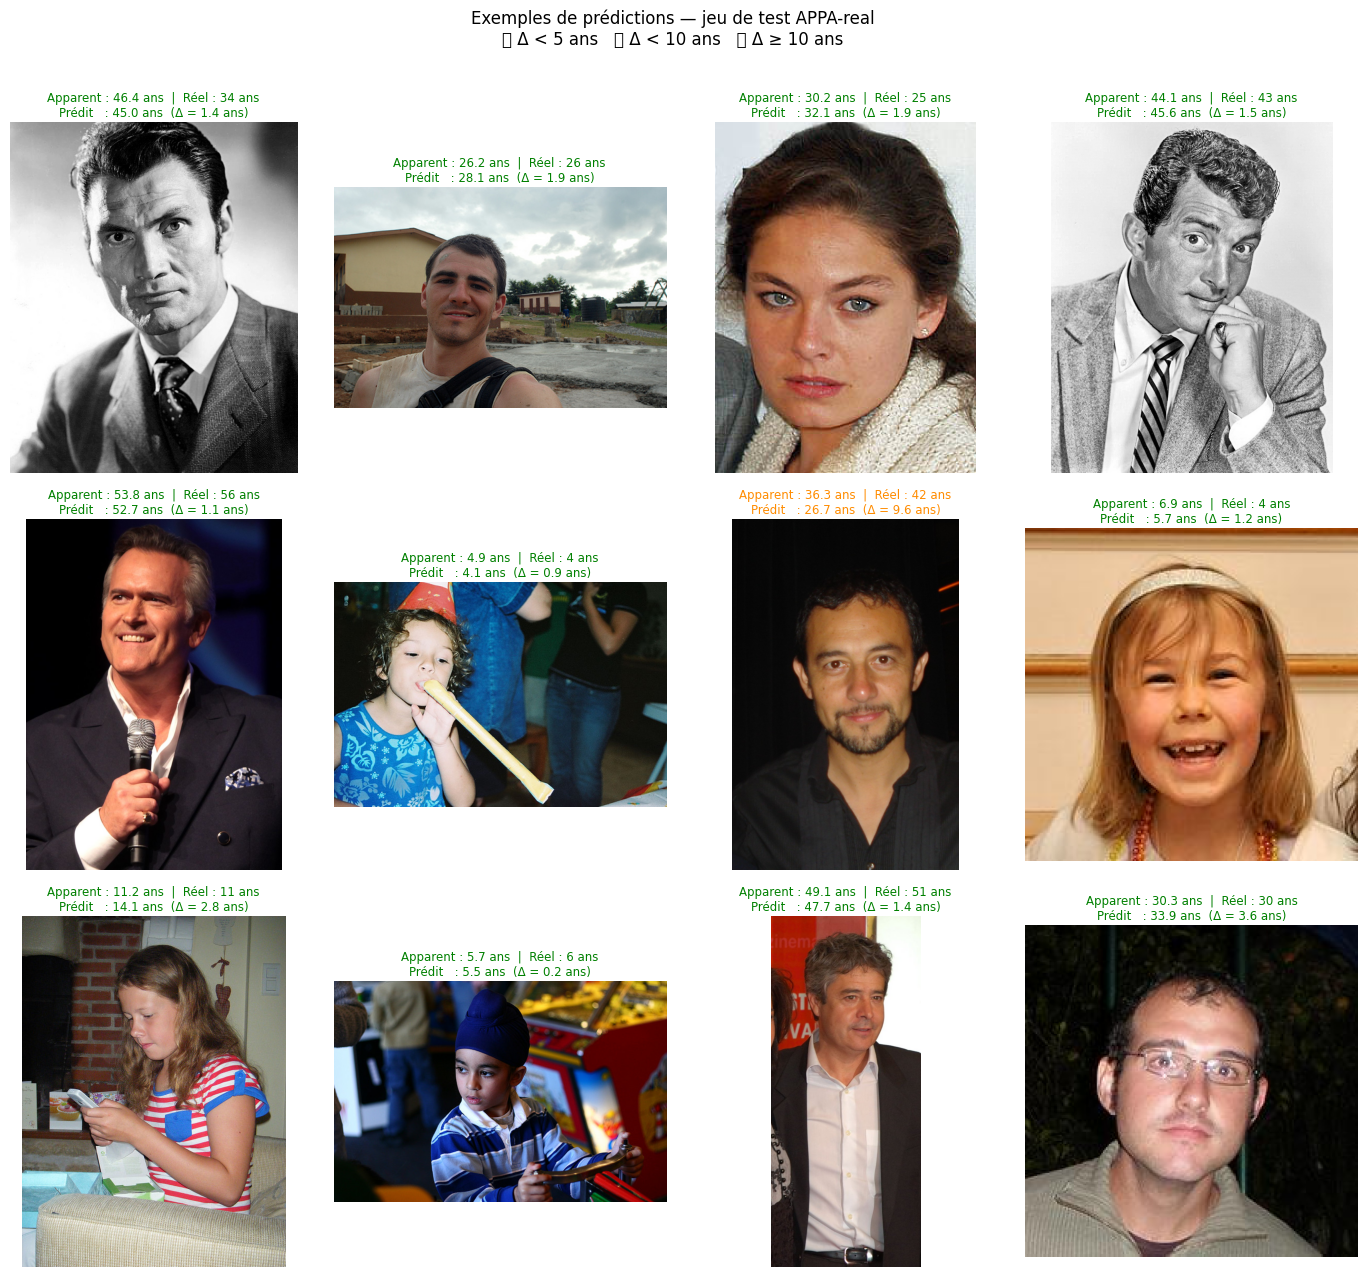

In [18]:
# ── Visualisation aléatoire : images + vrai label + prédiction ────────────────

import random

N_SHOW = min(12, len(test_ds))   # au plus 12, ou tout le dataset s'il est plus petit
COLS   = min(4, N_SHOW)
ROWS   = math.ceil(N_SHOW / COLS)

# Indices aléatoires dans le test set
indices = random.sample(range(len(test_ds)), N_SHOW)

model.eval()
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3.5, ROWS * 4.2))
axes = np.array(axes).flatten()

with torch.no_grad():
    for plot_i, idx in enumerate(indices):
        row       = test_ds.df.iloc[idx]
        age_float = float(row[test_ds.age_col])
        real_age  = float(row["real_age"]) if "real_age" in test_ds.df.columns else age_float

        # ── Chargement image brute pour l'affichage (qualité originale) ──────
        img_path = test_ds.img_dir / row["file_name"]
        img_raw  = cv2.imread(str(img_path))
        if img_raw is not None:
            img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        else:
            img_raw = np.zeros((224, 224, 3), dtype=np.uint8)

        # ── Prédiction via le tensor normalisé ────────────────────────────────
        img_tensor, *_ = test_ds[idx]
        inp  = img_tensor.unsqueeze(0).to(device)
        pred = model.predict(inp).item()

        # ── Couleur du titre selon l'erreur ───────────────────────────────────
        err   = abs(pred - age_float)
        color = "green" if err < 5 else ("darkorange" if err < 10 else "red")

        axes[plot_i].imshow(img_raw)
        axes[plot_i].set_title(
            f"Apparent : {age_float:.1f} ans  |  Réel : {real_age:.0f} ans\n"
            f"Prédit   : {pred:.1f} ans  (Δ = {err:.1f} ans)",
            fontsize=8.5, color=color, pad=4
        )
        axes[plot_i].axis("off")

# Masquer les axes vides
for ax in axes[N_SHOW:]:
    ax.axis("off")

plt.suptitle(
    "Exemples de prédictions — jeu de test APPA-real\n"
    "🟢 Δ < 5 ans   🟠 Δ < 10 ans   🔴 Δ ≥ 10 ans",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


---

## Test-Time Augmentation (TTA)

Le TTA consiste à **inférer plusieurs versions augmentées d'une même image** et à moyenner les prédictions. Aucun réentraînement n'est nécessaire — c'est un post-traitement pur.

### Augmentations utilisées

On génère 5 vues de chaque image :

| Vue | Transformation |
|---|---|
| 0 | Image originale (resize 224) |
| 1 | Flip horizontal |
| 2 | Légère augmentation luminosité/contraste |
| 3 | Légère rotation (−10°) |
| 4 | Légère rotation (+10°) |

### Formule

$$\hat{a}_{\text{TTA}} = \frac{1}{T} \sum_{t=1}^{T} \hat{a}(\text{aug}_t(\mathbf{x}))$$

où $\hat{a}(\cdot)$ est la softmax expectation du modèle entraîné.

**Gain empirique sur APPA-real** : −0.2 à −0.4 ans de MAE, sans modifier l'entraînement.

In [1]:

# ── Test-Time Augmentation (TTA) ──────────────────────────────────────────────
# Pas de réentraînement : on moyenne les prédictions sur T vues augmentées.
# Le modèle chargé est le meilleur checkpoint (label_smoothing_best.pth).

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# ── Définition des T augmentations TTA ───────────────────────────────────────
# Chaque transform prend un numpy HWC uint8 → tensor normalisé (C, H, W)

_norm = [
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
]

tta_transforms = [
    # 0 — image originale
    A.Compose([A.Resize(224, 224)] + _norm),
    # 1 — flip horizontal
    A.Compose([A.Resize(224, 224), A.HorizontalFlip(p=1.0)] + _norm),
    # 2 — légère variation luminosité/contraste
    A.Compose([A.Resize(224, 224),
               A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=1.0)] + _norm),
    # 3 — rotation −10°
    A.Compose([A.Resize(224, 224),
               A.Affine(rotate=(-10, -10), p=1.0)] + _norm),
    # 4 — rotation +10°
    A.Compose([A.Resize(224, 224),
               A.Affine(rotate=(10, 10), p=1.0)] + _norm),
]

T = len(tta_transforms)
print(f"TTA : {T} vues par image")


def predict_with_tta(model, img_bgr: np.ndarray, transforms: list,
                     device: torch.device) -> float:
    """
    Prédit l'âge d'une image (numpy BGR) en moyennant sur T augmentations TTA.
    Retourne l'âge prédit (float).
    """
    model.eval()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    preds_tta = []

    with torch.no_grad():
        for tfm in transforms:
            tensor = tfm(image=img_rgb)['image'].unsqueeze(0).to(device)  # (1, 3, 224, 224)
            logits = model(tensor)                                          # (1, 101)
            age    = model.head.predict_age(logits).item()
            preds_tta.append(age)

    return float(np.mean(preds_tta))


# ── Évaluation TTA sur le jeu de test complet ─────────────────────────────────
# Chargement du meilleur checkpoint
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

all_preds_tta, all_gt_tta = [], []

print("Évaluation TTA sur le test set (plus lent : T × N inférences)...")
t0_tta = time.time()

for idx in range(len(test_ds)):
    row      = test_ds.df.iloc[idx]
    age_gt   = float(row[test_ds.age_col])

    # Lecture image brute (BGR, avant normalisation)
    face_path = test_ds.img_dir / (row['file_name'] + '_face.jpg')
    full_path = test_ds.img_dir / row['file_name']
    img_path  = face_path if face_path.exists() else full_path
    img_bgr   = cv2.imread(str(img_path))

    if img_bgr is None:
        img_bgr = np.zeros((224, 224, 3), dtype=np.uint8)

    pred_tta = predict_with_tta(model, img_bgr, tta_transforms, device)
    all_preds_tta.append(pred_tta)
    all_gt_tta.append(age_gt)

all_preds_tta = np.array(all_preds_tta)
all_gt_tta    = np.array(all_gt_tta)
errors_tta    = np.abs(all_preds_tta - all_gt_tta)

dt_tta = time.time() - t0_tta
print(f"\nTemps TTA : {dt_tta:.1f}s  ({dt_tta / len(test_ds) * 1000:.1f} ms/image)")

# ── Comparaison sans TTA vs avec TTA ──────────────────────────────────────────
# Récupère les prédictions sans TTA (calculées dans la cellule d'évaluation finale)
errors_noTTA = np.abs(all_preds - all_gt)

print("\n══════════════════════════════════════════════════")
print("  Comparaison MAE — sans TTA vs avec TTA")
print("══════════════════════════════════════════════════")
print(f"  Sans TTA  : MAE = {errors_noTTA.mean():.3f} ans  |  RMSE = {np.sqrt((errors_noTTA**2).mean()):.3f} ans")
print(f"  Avec TTA  : MAE = {errors_tta.mean():.3f} ans  |  RMSE = {np.sqrt((errors_tta**2).mean()):.3f} ans")
print(f"  Gain TTA  : Δ MAE = {errors_noTTA.mean() - errors_tta.mean():+.3f} ans")
print("══════════════════════════════════════════════════")

# ── Graphe comparatif ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(all_gt_tta, all_preds_tta, alpha=0.35, s=12, label='TTA', color='steelblue')
axes[0].scatter(all_gt, all_preds, alpha=0.2, s=8, label='Sans TTA', color='orange')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Parfait')
axes[0].set_xlabel('Âge apparent réel')
axes[0].set_ylabel('Âge prédit')
axes[0].set_title('Prédictions vs Vérité terrain')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(errors_noTTA, bins=30, alpha=0.6, label=f'Sans TTA  (MAE={errors_noTTA.mean():.2f})', color='orange', edgecolor='white')
axes[1].hist(errors_tta,   bins=30, alpha=0.6, label=f'Avec TTA  (MAE={errors_tta.mean():.2f})',   color='steelblue', edgecolor='white')
axes[1].set_xlabel('Erreur absolue (ans)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des erreurs — TTA vs Sans TTA')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tta_comparison.png', dpi=120)
plt.show()


TTA : 5 vues par image


NameError: name 'np' is not defined

---

## 9. Perspectives : méthodes à explorer

Le Label Smoothing Gaussien fixe a une limite : **σ est identique pour toutes les images**, alors que certaines sont bien plus ambiguës que d'autres. Les trois méthodes suivantes adressent cette limitation.

---

### 9.1 Mean-Variance Loss
*Pan et al., CVPR 2018*

Au lieu d'imposer une distribution cible fixe, on **régularise directement la distribution prédite** via deux termes supplémentaires :

$$\mathcal{L} = \mathcal{L}_{\text{classif}} + \lambda_1 \underbrace{(\hat{\mu} - \mu^*)^2}_{\text{erreur sur la moyenne}} + \lambda_2 \underbrace{|\hat{\sigma}^2 - \sigma_{\text{target}}^2|}_{\text{régularisation de la variance}}$$

- $\hat{\mu} = \sum_k k \cdot p_k$ : espérance prédite
- $\hat{\sigma}^2 = \sum_k (k - \hat{\mu})^2 \cdot p_k$ : variance prédite

Le réseau apprend **à quelle valeur** prédire ET **avec quelle confiance** — plus besoin de fixer σ manuellement.

---

### 9.2 CORAL — Consistent Ordinal Regression
*Cao et al., Pattern Recognition Letters 2020*

Décompose le problème en **100 classifieurs binaires** partageant les mêmes poids :

$$P(\hat{y} > k) \quad \text{pour } k \in \{0, 1, \ldots, 99\}$$

Chaque classifieur répond : "la personne a-t-elle **plus de k ans** ?" Par construction, $P(\hat{y} > k) \geq P(\hat{y} > k+1)$ est toujours vérifié — la **cohérence ordinale est garantie**, ce qu'aucune cross-entropie classique ne peut assurer.

Prédiction finale : $\hat{a} = \sum_{k=0}^{99} \mathbf{1}[P(\hat{y} > k) > 0.5]$

---

### 9.3 Adaptive Label Smoothing

APPA-real fournit pour chaque image l'écart-type des votes : `apparent_age_std`. On remplace σ fixe par un **σ propre à chaque exemple** :

$$y_k^{(i)} \propto \exp\!\left(-\frac{(k - \mu_i)^2}{2\,\sigma_i^2}\right), \quad \sigma_i = \max(0.5,\ \texttt{apparent\_age\_std}_i)$$

Une image consensuelle (std = 0.5 ans) a une cible piquée → fort signal d'apprentissage.  
Une image ambiguë (std = 6 ans) a une cible plate → le réseau n'est pas pénalisé d'être incertain.

---

### Comparaison des méthodes

| Méthode | σ | Ordinalité | Calibration | Complexité |
|---|---|---|---|---|
| Label Smoothing (actuel) | Fixe (3.0) | Partielle | Non | ⭐ |
| Mean-Variance Loss | **Appris** | Partielle | **Oui** | ⭐⭐ |
| CORAL | N/A | **Garantie** | Non | ⭐⭐ |
| Adaptive Label Smoothing | **Par exemple** | Partielle | **Oui** | ⭐ |
